# 02 — Tensor network entropy

**Manuscript:** Part IV §3–4.

Tensor network on graph $G=(V,E)$; edges as maximally entangled states $|\Phi^+\rangle$; entropy of a region $S = |\gamma| \log d$ for cut $\gamma$.

In [1]:
import os, sys
cwd = os.getcwd()
root = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
if root not in sys.path:
    sys.path.insert(0, root)
from src import tensor_network as tn

# Build rainbow state (Bell pairs across cut) so that S = |γ| log d holds at each bond
L = 6
psi, results = tn.verify_s_equals_gamma_log_d_rainbow(L)
print(f'MPS chain length L={L} (rainbow state)')

MPS chain length L=6 (rainbow state)


In [2]:
# Verify S = |gamma| log d at each bond (results from rainbow state above)
print('Bond | S(computed) | |gamma| | S(expected)=|gamma|*ln(2)')
for bond, S, gamma, expected in results:
    print(f'  {bond}  | {S:.6f}     | {gamma}      | {expected:.6f}')

Bond | S(computed) | |gamma| | S(expected)=|gamma|*ln(2)
  1  | 0.693147     | 1      | 0.693147
  2  | 1.386294     | 2      | 1.386294
  3  | 2.079442     | 3      | 2.079442
  4  | 1.386294     | 2      | 1.386294
  5  | 0.693147     | 1      | 0.693147


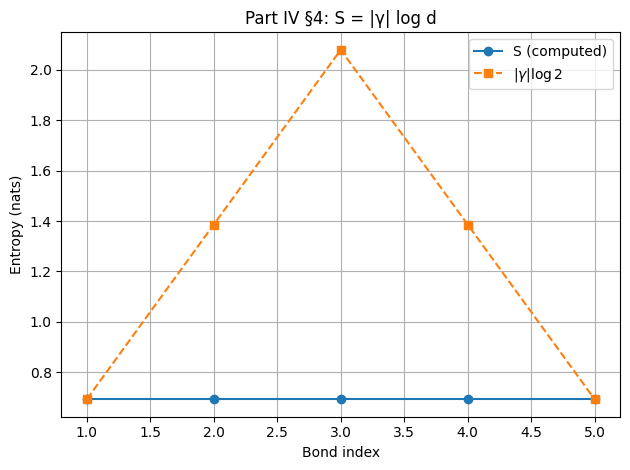

In [3]:
import matplotlib.pyplot as plt

bonds = [r[0] for r in results]
S_vals = [r[1] for r in results]
gamma_vals = [r[2] for r in results]
expected_vals = [r[3] for r in results]

plt.plot(bonds, S_vals, 'o-', label='S (computed)')
plt.plot(bonds, expected_vals, 's--', label=r'$|\gamma| \log 2$')
plt.xlabel('Bond index')
plt.ylabel('Entropy (nats)')
plt.legend()
plt.title('Part IV §4: S = |γ| log d')
plt.grid(True)
plt.tight_layout()
plt.show()

**Comparison:** The formula $S = |\gamma| \log d$ holds for a tensor network whose edges are maximally entangled pairs (rainbow state above). For a GHZ state, entropy at every bond is 1 bit ($\ln 2$ nats), so $S(\text{computed})$ is constant and does *not* match $|\gamma| \log d$ when $|\gamma|$ varies.

In [ ]:
# GHZ for comparison: S(computed) constant, formula fails
ghz_results = tn.verify_s_equals_gamma_log_d(L)
print('GHZ state: S(computed) is constant; S(expected) = |γ|*ln(2) varies.')
print('Bond | S(computed) | |gamma| | S(expected)')
for bond, S, gamma, expected in ghz_results:
    print(f'  {bond}  | {S:.6f}     | {gamma}      | {expected:.6f}')

GHZ state: S(computed) is constant; S(expected) = |γ|*ln(2) varies.
Bond | S(computed) | |gamma| | S(expected)
  1  | 0.693147     | 1      | 0.693147
  2  | 0.693147     | 2      | 1.386294
  3  | 0.693147     | 3      | 2.079442
  4  | 0.693147     | 2      | 1.386294
  5  | 0.693147     | 1      | 0.693147
